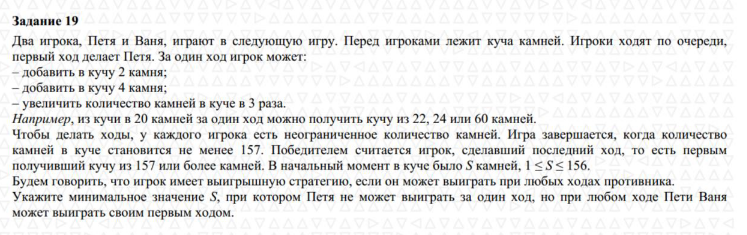

In [1]:
def F(x, m):
    if x >= 157:
        return m % 2 == 0
    if m == 0:
        return 0
    h = [F(x + 2, m - 1), F(x + 4, m - 1), F(x * 3, m - 1)]
    return any(h) if m % 2 != 0 else all(h)
print([x for x in range(1, 157) if F(x,2)])

[51, 52]


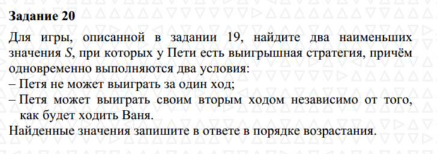

In [3]:
print([x for x in range(1, 157) if not F(x,1) and F(x, 3)])

[17, 47, 48, 49, 50]


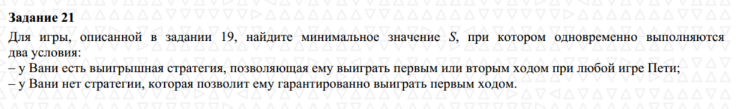

In [4]:
print([x for x in range(1, 157) if not F(x,2) and F(x, 4)])

[45, 46]


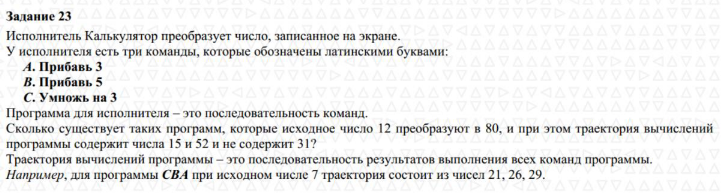

In [5]:
def F(x, y):
    if x > y  or x == 31:
        return 0
    if x == y:
        return 1
    return F(x + 3, y) + F(x + 5, y) + F(x * 3, 3)
print(F(12, 15) * F(15, 52) * F(52, 80))

3910


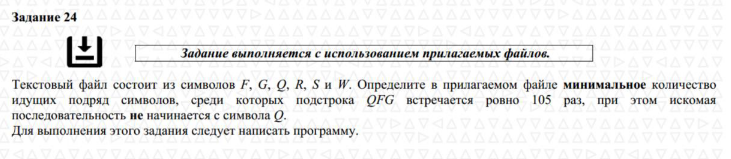

In [9]:
s = open('24.txt').read().split('QFG')
minn = 99999
for i in range(len(s) - 105):
    if s[i].lstrip('Q'):
        minn = min(minn, len(''.join(s[i:i + 104]).lstrip('Q')) + 105 * 3)
print(minn)

378


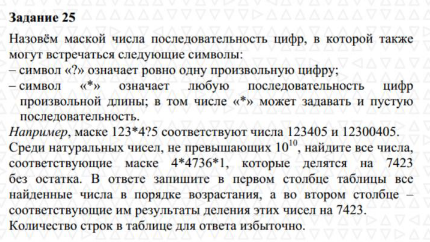

In [10]:
from fnmatch import fnmatch
for x in range(7423, 10 ** 10, 7423):
    if fnmatch(str(x), '4*4736*1'):
        print(x, x // 7423)

443947361 59807
447361941 60267
4047368481 545247
4155447361 559807
4204736081 566447
4473671371 602677
4647369571 626077
4874736061 656707
4897747361 659807


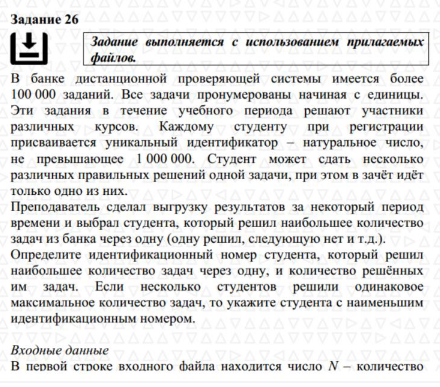

In [28]:
N, *data = [[int(x) for x in line.strip().split()] for line in open('26.txt')]
data.sort(key = lambda x: (x[0], x[1]))
counter = 1
M = []
for i in range(1, len(data)):
    if data[i - 1][0] == data[i][0]:
        if data[i][1] - data[i - 1][1] == 2:
            counter += 1
        elif data[i][1] - data[i - 1][1] > 2 or data[i][1] - data[i - 1][1] == 1:
            M.append([data[i - 1][0], counter])
            counter = 1
        elif data[i][1] - data[i - 1][1] == 0:
            continue
    else:
        counter = 1
M.sort(key = lambda x: (-x[1], x[0]))
print(M[0])

[10031, 26]


In [27]:
from collections import defaultdict

def count_seq(ts):
    max_counter = 1
    cur_counter = 1
    for i in range(1, len(ts)):
        if ts[i] == ts[i-1] + 2:
            cur_counter += 1
        else:
            max_counter = max(max_counter, cur_counter)
            cur_counter = 1
    return max_counter

S = defaultdict(set)
N, *data = [[int(x) for x in line.strip().split()] for line in open('26.txt')]
for s, t in data:
    S[s].add(t)
min_s = 9999999999999999999999
max_t = -1
for s, ts in S.items():
    if (t:=count_seq(sorted(ts))) >= max_t and min_s > s:
        min_s = s
        max_t = t
print(min_s, max_t)

10031 26


In [14]:
min(S[66772])

64113

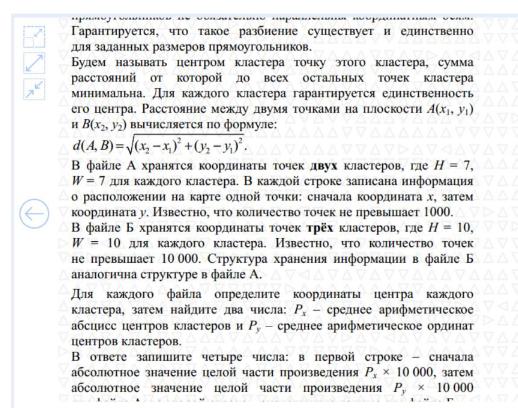

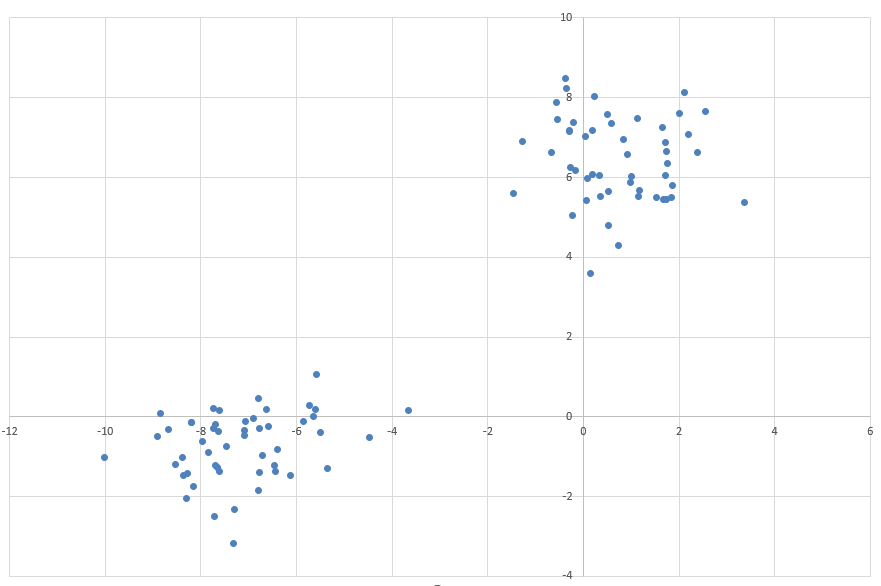

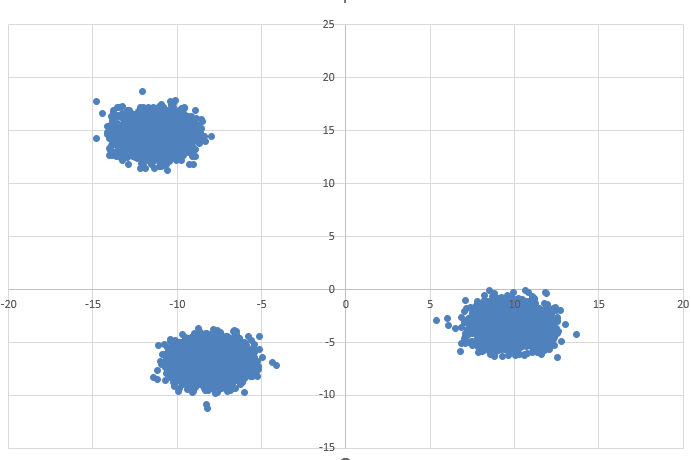

In [39]:
from math import dist
data = [[float(x) for x in line.split()] for line in open('27_B.txt')]
clusters = []
centroids = []

r = 5
while data:
    clusters.append([data.pop()])
    for p1 in clusters[-1]:
        nado = [p for p in data if dist(p1, p) < r]
        clusters[-1].extend(nado)
        for p in nado:
            data.remove(p)
    
for cluster in clusters:
    minn = 999999999
    centroid = 0
    for p1 in cluster:
        summ = sum(dist(p1, p) for p in cluster)
        if summ < minn:
            minn = summ
            centroid = p1
    centroids.append(centroid)
print(centroids)

Px = sum(x for x, y in centroids) / len(centroids)
Py = sum(y for x, y in centroids) / len(centroids)
print(abs(int(Px * 10_000)), abs(int(Py * 10_000)))


[[-11.283477797110457, 14.582515451259606], [-7.993740044801888, -6.907190895104232], [9.840032985917304, -3.441194544849973]]
31457 14113
